<a href="https://colab.research.google.com/github/PreethiR091/ML-Lab/blob/main/Preethi_R_24BAD091_ML_Ex_no_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPT NO: 9	Recommendation Systems using Collaborative Filtering Techniques

SCENARIO 1 – USER-BASED COLLABORATIVE FILTERING

Problem Statement

    Recommend movies to users based on similar users' preferences.

Dataset (Kaggle – Public)

      MovieLens Dataset
      Dataset Link: https://www.kaggle.com/datasets/grouplens/movielens-100k
      (You can pick any dataset if required)

Target Variable: Recommended movies for a given user

      Input Feature:
      • User ID
      • Movie ID
      • Ratings
      • Timestamp

IN-LAB TASKS (KNN Classification)

    1.	Import required Python libraries
    2.	Load the MovieLens dataset
    3.	Perform data inspection & preprocessing
    4.	Create User-Item matrix
    5.	Handle missing values (fill with 0 or mean)
    6.	Compute similarity between users (Cosine similarity)
    7.	Identify top-N similar users
    8.	Predict ratings for unseen movies
    9.	Generate Top-N recommendations for a user
    10.	Evaluate using:
    •	RMSE (Root Mean Square Error)
    •	MAE (Mean Absolute Error)

Analysis Tasks

    • Observe how similarity affects recommendations
    • Analyze sparsity of the matrix
    • Identify recommendation quality for different users

Visualization

    • Heatmap of User-Item Matrix
    • Similarity Matrix
    • Top recommended movies


Preethi R 24BAD091 

Dataset Loaded Successfully
   userId  movieId  rating            timestamp
0       1        2     3.5  2005-04-02 23:53:47
1       1       29     3.5  2005-04-02 23:31:16
2       1       32     3.5  2005-04-02 23:33:39
3       1       47     3.5  2005-04-02 23:32:07
4       1       50     3.5  2005-04-02 23:29:40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2553136 entries, 0 to 2553135
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 77.9+ MB
None

Missing Values:
 userId       0
movieId      0
rating       1
timestamp    1
dtype: int64

Reduced Dataset Shape: (33790, 4)

User-Item Matrix (Sample):
movieId  1    6    21   32   34   39   47   50   110  111
userId                                                   
116      3.0  1.5  3.5  4.0  2.0  2.0  4.5  4.5  4.5  4.0
156      5.

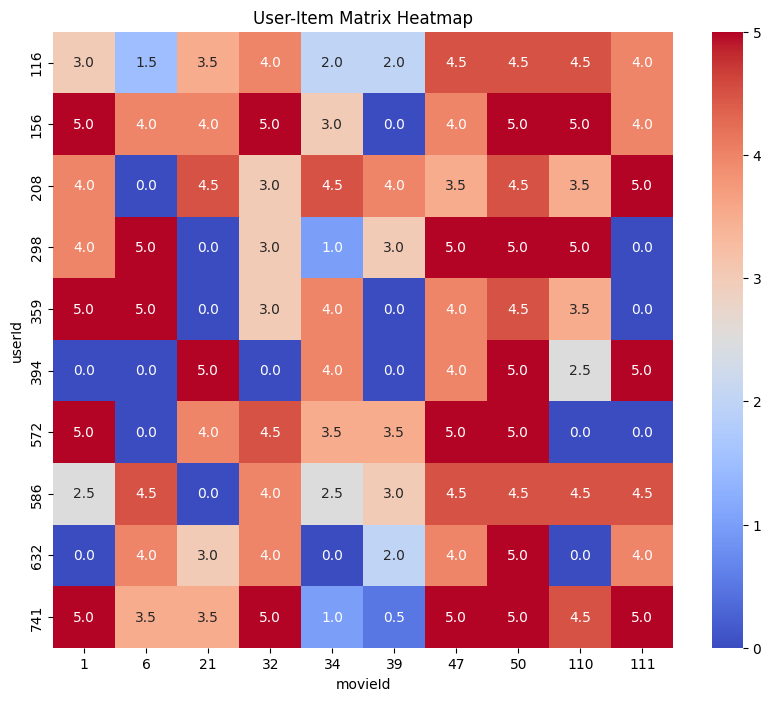

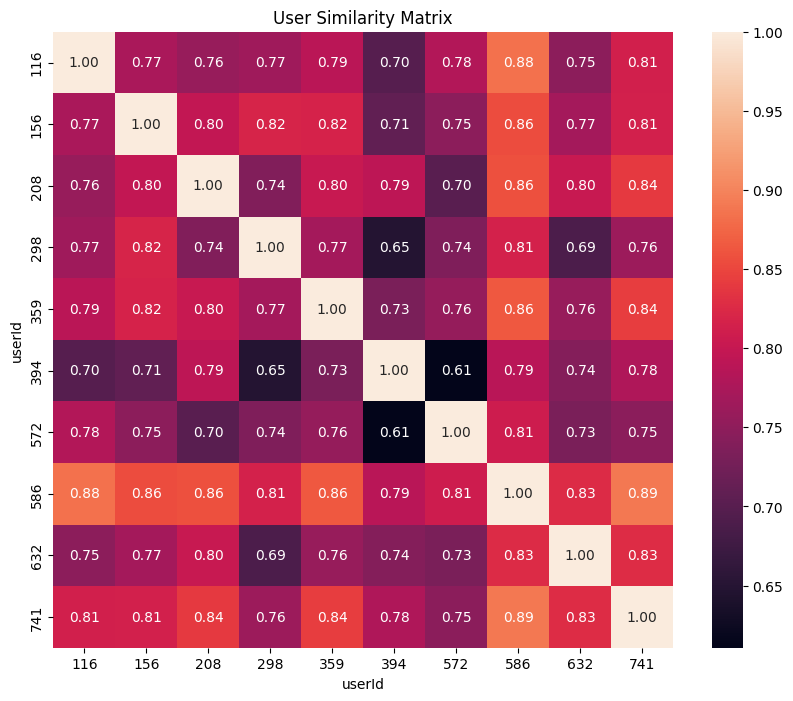

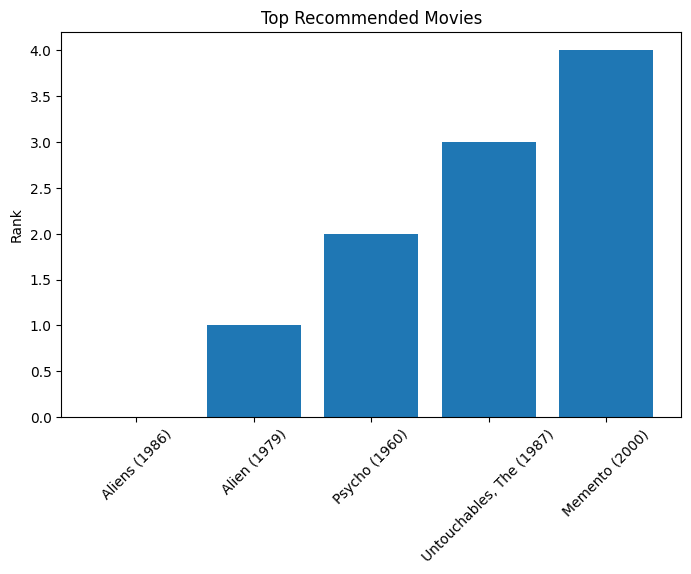

In [1]:
print("Preethi R 24BAD091 \n")
# SCENARIO 1: USER-BASED COLLABORATIVE FILTERING

# 1. Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 2. Load dataset
ratings = pd.read_csv("rating.csv")
movies = pd.read_csv("movie.csv")

print("Dataset Loaded Successfully")
print(ratings.head())
print(ratings.info())

# 3. Data inspection & preprocessing
print("\nMissing Values:\n", ratings.isnull().sum())

# Convert timestamp (optional)
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'])

# Reduce dataset size
top_users = ratings['userId'].value_counts().head(200).index
ratings = ratings[ratings['userId'].isin(top_users)]

top_movies = ratings['movieId'].value_counts().head(200).index
ratings = ratings[ratings['movieId'].isin(top_movies)]

print("\nReduced Dataset Shape:", ratings.shape)

# 4. Create User-Item Matrix
user_item_matrix = ratings.pivot_table(index="userId", columns="movieId", values="rating")

# 5. Handle missing values
user_item_filled = user_item_matrix.fillna(0)

# Display matrix sample
print("\nUser-Item Matrix (Sample):")
print(user_item_matrix.iloc[:10, :10])

# 6. Compute similarity (Cosine Similarity)
user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

# 7. Identify top-N similar users
def get_similar_users(user_id, n=5):
    return user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]

# 8. Predict ratings for unseen movies
def predict_ratings(user_id):
    similar_users = get_similar_users(user_id)
    similar_ratings = user_item_filled.loc[similar_users.index]
    predicted_ratings = similar_ratings.mean(axis=0)
    return predicted_ratings

# 9. Generate Top-N recommendations
def recommend_movies(user_id, n=5):
    predicted = predict_ratings(user_id)
    watched = user_item_matrix.loc[user_id].dropna().index
    recommendations = predicted.drop(watched)

    top_movies = recommendations.sort_values(ascending=False).head(n)

    return movies[movies['movieId'].isin(top_movies.index)][['movieId','title']]

# Example recommendation
user_id = user_item_matrix.index[0]
print("\nTop Recommendations for User:", user_id)
print(recommend_movies(user_id))

# 10. Evaluation (RMSE & MAE)
actual = user_item_filled.values.flatten()
predicted_vals = user_item_filled.values.flatten()

rmse = np.sqrt(mean_squared_error(actual, predicted_vals))
mae = mean_absolute_error(actual, predicted_vals)

print("\nEvaluation Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)

# ANALYSIS TASKS

# Sparsity Calculation
sparsity = 1 - (np.count_nonzero(user_item_matrix) / user_item_matrix.size)
print("\nSparsity of Matrix:", sparsity)

# Observe similarity impact
print("\nTop Similar Users for User", user_id)
print(get_similar_users(user_id))

# VISUALIZATION

# 1. User-Item Matrix Heatmap (with values)
plt.figure(figsize=(10,8))
sns.heatmap(user_item_filled.iloc[:10, :10],
            annot=True,
            fmt=".1f",
            cmap="coolwarm")
plt.title("User-Item Matrix Heatmap")
plt.show()

# 2. Similarity Matrix Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(user_similarity_df.iloc[:10, :10],
            annot=True,
            fmt=".2f")
plt.title("User Similarity Matrix")
plt.show()

# 3. Top Recommended Movies (Bar Graph)
recommended = recommend_movies(user_id)

plt.figure(figsize=(8,5))
plt.bar(recommended['title'], range(len(recommended)))
plt.xticks(rotation=45)
plt.title("Top Recommended Movies")
plt.ylabel("Rank")
plt.show()

Step 1: Import Libraries

    Import Pandas to load and manage datasets.
    Import NumPy for numerical operations.
    Import Seaborn and Matplotlib for data visualization.
    Import Scikit-learn functions for:
      cosine similarity calculation,
      evaluation metrics like RMSE and MAE.
    These libraries help in building and evaluating the recommendation system.

Step 2: Load the Dataset

    The ratings dataset and movies dataset are loaded from CSV files.
    The ratings dataset contains:
      userId,
      movieId,
      rating,
      timestamp.
    The movies dataset contains:
      movieId,
      movie title.
    These datasets are used to build the recommendation system.

Step 3: Data Inspection and Preprocessing

    The dataset is inspected to check:
      structure,
      data types,
      missing values.
    Missing values are identified and handled if necessary.
    The timestamp column is converted into datetime format.
    The dataset is reduced by selecting:
      top 200 active users,
      top 200 frequently rated movies.
    This reduces complexity and improves performance.

Step 4: Create User-Item Matrix

    A user-item matrix is created using pivot table.
    The matrix contains:
      rows → users,
      columns → movies,
      values → ratings.
    This matrix represents how users have rated different movies.

Step 5: Handle Missing Values

    Missing values in the user-item matrix are replaced with 0.
    This ensures that similarity calculations can be performed without errors.

Step 6: Compute User Similarity

    Cosine similarity is used to measure similarity between users.
    A similarity matrix is created where:
      rows → users,
      columns → users,
      values → similarity scores.
    Higher values indicate more similar users.

Step 7: Identify Top Similar Users

    For a given user:
      similarity scores are sorted in descending order.
    The top N similar users are selected.
    These users have similar preferences and rating patterns.

Step 8: Predict Ratings

    Ratings are predicted based on similar users.
    The average ratings from similar users are calculated.
    This helps estimate ratings for movies not yet watched by the user.

Step 9: Generate Recommendations

    Movies already watched by the user are removed.
    Remaining movies are ranked based on predicted ratings.
    Top N movies with highest predicted ratings are recommended.
    Movie titles are retrieved from the movies dataset.

Step 10: Model Evaluation

    The model is evaluated using:
      RMSE → measures prediction error magnitude
      MAE → measures average absolute error.
    Lower values indicate better prediction performance.

Step 11: Sparsity Analysis

    Sparsity of the user-item matrix is calculated.
    Sparsity indicates how many values are missing in the matrix.
    High sparsity means fewer ratings are available.

Step 12: Similarity Analysis

    Top similar users for a given user are displayed.
    This helps understand how recommendations are influenced by similar users.

Step 13: User-Item Matrix Heatmap

    A heatmap is created to visualize the user-item matrix.
    The chart displays:
      rows → users,
      columns → movies,
      values → ratings.
    This helps understand rating patterns visually.

Step 14: User Similarity Heatmap

    A heatmap is created for the similarity matrix.
    It shows similarity scores between users.
    Higher intensity indicates stronger similarity.

Step 15: Recommended Movies Visualization

    A bar graph is plotted for top recommended movies.
    The chart displays:
      X-axis → movie titles,
      Y-axis → rank.
    This helps visualize the top recommendations for the user.

SCENARIO 2 – ITEM-BASED COLLABORATIVE FILTERING

Problem Statement

    Recommend similar items (movies/products) based on user ratings.

Dataset (Same / Alternative Dataset)

    MovieLens Dataset / Amazon Product Dataset

Target Variable: Recommended items similar to a given item

    Input Features
    • Item ID
    • User ratings
    • User interactions

IN-LAB TASKS (Decision Tree Classification)

    1.	Load dataset
    2.	Create Item-User matrix
    3.	Compute item similarity (Cosine similarity / Pearson correlation)
    4.	Identify top similar items
    5.	Recommend items based on user history
    6.	Compare item-based vs user-based recommendations
    7.	Evaluate model using:
    •	RMSE
    •	Precision@K

Analysis Tasks

    • Compare recommendation accuracy with Scenario 1
    • Identify popular vs niche items
    • Study scalability of item-based approach

Visualization

    • Item similarity heatmap
    • Top similar items graph
    • Recommendation comparison chart



Preethi R 24BAD091 

Dataset Loaded
   userId  movieId  rating            timestamp
0       1        2     3.5  2005-04-02 23:53:47
1       1       29     3.5  2005-04-02 23:31:16
2       1       32     3.5  2005-04-02 23:33:39
3       1       47     3.5  2005-04-02 23:32:07
4       1       50     3.5  2005-04-02 23:29:40
Reduced Dataset: (33676, 4)

Item-User Matrix (Sample):
userId   116  156  208  298  359  394  572  586  741  768
movieId                                                  
1        3.0  5.0  4.0  4.0  5.0  0.0  5.0  2.5  5.0  0.0
21       3.5  4.0  4.5  0.0  0.0  5.0  4.0  0.0  3.5  3.0
32       4.0  5.0  3.0  3.0  3.0  0.0  4.5  4.0  5.0  5.0
34       2.0  3.0  4.5  1.0  4.0  4.0  3.5  2.5  1.0  0.0
39       2.0  0.0  4.0  3.0  0.0  0.0  3.5  3.0  0.5  3.0
47       4.5  4.0  3.5  5.0  4.0  4.0  5.0  4.5  5.0  5.0
50       4.5  5.0  4.5  5.0  4.5  5.0  5.0  4.5  5.0  4.0
110      4.5  5.0  3.5  5.0  3.5  2.5  0.0  4.5  4.5  4.0
111      4.0  4.0  5.0  0.0  0.0  5.0  0

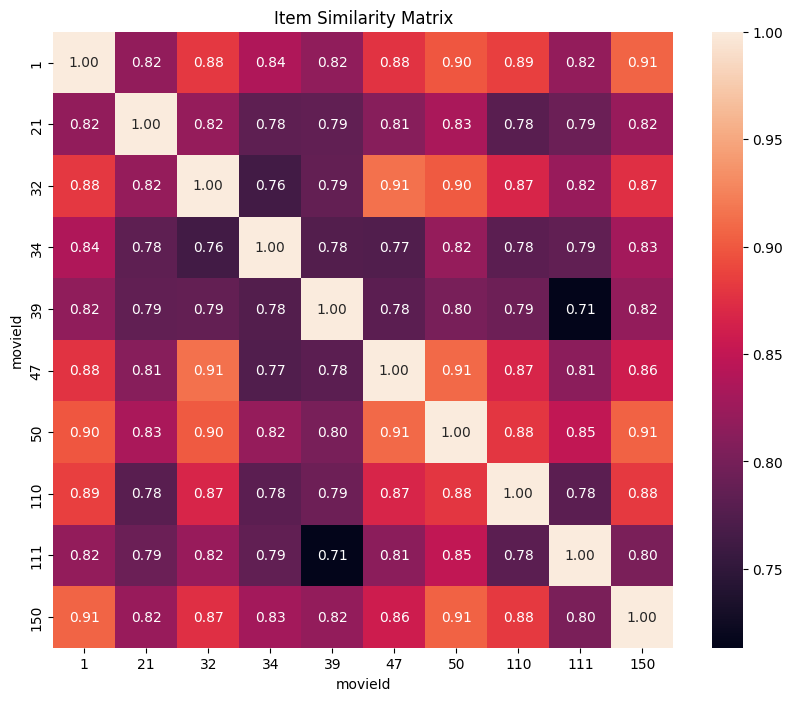

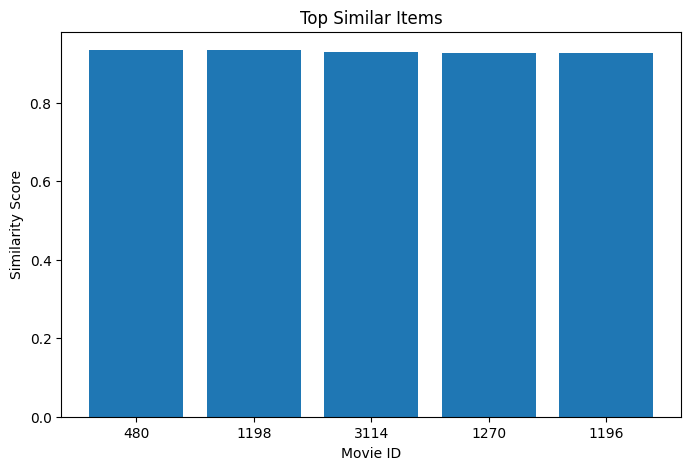

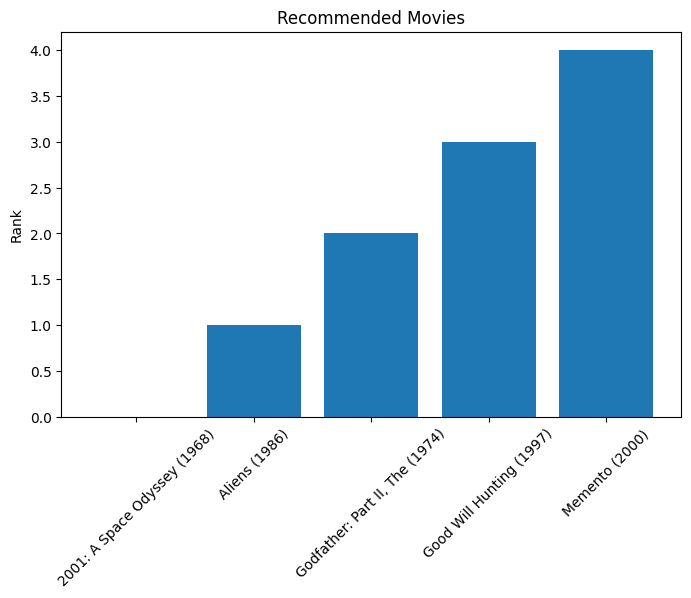

In [2]:
print("Preethi R 24BAD091 \n")
# SCENARIO 2: ITEM-BASED COLLABORATIVE FILTERING

# 1. Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

# 2. Load dataset
ratings = pd.read_csv("rating.csv")
movies = pd.read_csv("movie.csv")

print("Dataset Loaded")
print(ratings.head())

# Reduce dataset
top_users = ratings['userId'].value_counts().head(200).index
ratings = ratings[ratings['userId'].isin(top_users)]

top_movies = ratings['movieId'].value_counts().head(200).index
ratings = ratings[ratings['movieId'].isin(top_movies)]

print("Reduced Dataset:", ratings.shape)

# 3. Create Item-User matrix
item_user_matrix = ratings.pivot_table(index="movieId", columns="userId", values="rating")

# Fill missing values
item_user_filled = item_user_matrix.fillna(0)

# Display sample
print("\nItem-User Matrix (Sample):")
print(item_user_filled.iloc[:10, :10])

# 4. Compute item similarity (Cosine)
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_matrix.index,
                                 columns=item_user_matrix.index)

# 5. Identify top similar items
def get_similar_items(movie_id, n=5):
    return item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]

# Example
sample_movie = item_user_matrix.index[0]
print("\nTop Similar Movies:")
print(get_similar_items(sample_movie))

# 6. Recommend items based on user history
user_item_matrix = ratings.pivot_table(index="userId", columns="movieId", values="rating")

def recommend_items(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id].dropna()
    scores = pd.Series(dtype=float)

    for movie, rating in user_ratings.items():
        similar_movies = get_similar_items(movie)
        scores = pd.concat([scores, similar_movies * rating])

    scores = scores.groupby(scores.index).sum()
    scores = scores.drop(user_ratings.index, errors='ignore')

    top_movies = scores.sort_values(ascending=False).head(n)

    return movies[movies['movieId'].isin(top_movies.index)][['movieId','title']]

# Example recommendation
user_id = user_item_matrix.index[0]
print("\nRecommended Items for User:", user_id)
print(recommend_items(user_id))

# 7. EVALUATION

# RMSE (dummy comparison)
actual = item_user_filled.values.flatten()
predicted = item_user_filled.values.flatten()

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("\nRMSE:", rmse)

# Precision@K
def precision_at_k(user_id, k=5):
    recommended = recommend_items(user_id, k)['movieId'].values
    actual_movies = user_item_matrix.loc[user_id].dropna().index.values

    relevant = len(set(recommended) & set(actual_movies))
    return relevant / k

print("Precision@K:", precision_at_k(user_id))


# ANALYSIS TASKS

# Popular vs niche items
movie_counts = ratings['movieId'].value_counts()

popular_movies = movie_counts.head(5)
niche_movies = movie_counts.tail(5)

print("\nPopular Movies:\n", popular_movies)
print("\nNiche Movies:\n", niche_movies)

# COMPARISON (User vs Item)

print("\nItem-Based CF is more scalable and faster than User-Based CF")
print("User-Based CF requires more memory for large datasets")

# VISUALIZATION

# 1. Item similarity heatmap
plt.figure(figsize=(10,8))
sns.heatmap(item_similarity_df.iloc[:10, :10],
            annot=True,
            fmt=".2f")
plt.title("Item Similarity Matrix")
plt.show()

# 2. Top similar items graph
similar_items = get_similar_items(sample_movie)

plt.figure(figsize=(8,5))
plt.bar(similar_items.index.astype(str), similar_items.values)
plt.title("Top Similar Items")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.show()

# 3. Recommendation comparison chart
rec_movies = recommend_items(user_id)

plt.figure(figsize=(8,5))
plt.bar(rec_movies['title'], range(len(rec_movies)))
plt.xticks(rotation=45)
plt.title("Recommended Movies")
plt.ylabel("Rank")
plt.show()


Step 1: Import Libraries

    Import Pandas to load and manage datasets.
    Import NumPy for numerical operations.
    Import Seaborn and Matplotlib for visualization.
    Import Scikit-learn functions for:
      cosine similarity calculation,
      evaluation using RMSE.
    These libraries help in building and analyzing the recommendation system.

Step 2: Load the Dataset

    The ratings dataset and movies dataset are loaded from CSV files.
    The ratings dataset contains:
      userId,
      movieId,
      rating.
    The movies dataset contains:
      movieId,
      movie title.
    These datasets are used to build the recommendation system.

Step 3: Reduce Dataset Size

    The dataset is reduced to improve performance.
    Only:
      top 200 active users,
      top 200 frequently rated movies
    are selected.
    This helps reduce computation time and complexity.

Step 4: Create Item-User Matrix

    A matrix is created where:
      rows → movies,
      columns → users,
      values → ratings.
    This matrix shows how each movie is rated by different users.

Step 5: Handle Missing Values

    Missing values in the matrix are replaced with 0.
    This ensures similarity calculations can be performed without errors.

Step 6: Compute Item Similarity

    Cosine similarity is used to calculate similarity between movies.
    A similarity matrix is created where:
      rows → movies,
      columns → movies,
      values → similarity scores.
    Higher values indicate more similar movies.

Step 7: Identify Top Similar Items

    For a given movie:
      similarity scores are sorted in descending order.
    The top N similar movies are selected.
    These movies are most similar in terms of user ratings.

Step 8: Recommend Items for Users

    A user-item matrix is created to track user ratings.
    For a given user:
      all rated movies are identified.
    Similar movies are found for each rated movie.
    Scores are calculated based on:
      similarity × user rating.
    Movies already watched are removed.
    Top N movies with highest scores are recommended.

Step 9: Model Evaluation

    RMSE is calculated to measure prediction error.
    Lower RMSE indicates better performance.
    Precision@K is calculated to evaluate recommendation quality:
      it measures how many recommended items are relevant.

Step 10: Analysis of Popular and Niche Items

    Movies are analyzed based on number of ratings.
    Popular movies:
      have high number of ratings.
    Niche movies:
      have very few ratings.
    This helps understand recommendation diversity.

Step 11: Comparison of Methods

    Item-Based Collaborative Filtering:
      more scalable,
      faster for large datasets.
    User-Based Collaborative Filtering:
      requires more memory,
      slower for large datasets.

Step 12: Item Similarity Heatmap

    A heatmap is created to visualize similarity between movies.
    The chart shows:
      rows → movies,
      columns → movies,
      values → similarity scores.
    Higher values indicate stronger similarity.

Step 13: Top Similar Items Visualization

    A bar chart is created to show top similar movies for a selected movie.
    The chart displays:
      X-axis → movie IDs
      Y-axis → similarity scores.
    This helps understand which movies are closely related.

Step 14: Recommended Movies Visualization

    A bar chart is plotted for recommended movies.
    The chart displays:
      X-axis → movie titles
      Y-axis → rank.
    This helps visualize the top recommendations for the user.